In [1]:
import random
import numpy as np

class GridWorld:
    def __init__(self, rows = 4, cols = 4, max_steps = 30):
        self.rows = rows
        self.cols = cols
        self.start_state = (rows-1, 0)
        self.goal_state = (0,0)
        self.max_steps = max_steps
        self.reset()

    def reset(self):
        """
        Reset the environment at the beginning of an episode.
        Returns the starting state.
        """
        self.state = self.start_state
        self.steps = 0
        return self.state

    def step(self, action):
        """
        Apply only one action.

        Input: 
            action: one of ["up", "down", "left", "right"]

        Returns: 
            next_state: the new state after the action
            reward: reward recieved after the action
            done: True if the episode is over, False otherwise
        """
        row, col = self.state
        new_row, new_col = row, col

        if action == "up":
            new_row = row-1
        elif action == "down":
            new_row = row+1
        elif action == "left":
            new_col = col-1
        elif action == "right":
            new_col = col+1
        else:
            raise ValueError("Unknown action: " + str(action))


        out_of_bounds = (new_row > self.rows or new_row < 0 or new_col > self.cols or new_col < 0)
        if out_of_bounds:
            new_row, new_col = row, col

        next_state = (new_row, new_col)
        self.state = next_state
        self.steps += 1

        if next_state == self.goal_state:
            reward = 10
            done = True
        elif self.steps >= self.max_steps:
            reward = -1
            done = False
        else:
            reward = -1
            done = False

        return next_state, reward, done



In [2]:
env = GridWorld()
print(env.reset())
print(env.step("up"))

(3, 0)
((2, 0), -1, False)


In [3]:
def random_policy(state):
    actions = ["up", "down", "left", "right"]
    return random.choice(actions)

def simple_policy(state):
    row, col = state

    if row > 0:
        return "up"
    if col > 0:
        return "left"

    return "up"


def run_episode(env, policy, print_steps = False):
    state = env.reset()
    trajectory = []
    done = False

    while not done:
        action = simple_policy(state)
        next_state, reward, done = env.step(action)
        trajectory.append((state, action, reward, next_state))

        if print_steps:
            print("State:", state, ", ",
                  "Action:", action, ", ",
                  "Reward:", reward, ", ",
                  "Next state:", next_state)

        state = next_state

    return trajectory

In [4]:
trajectory = run_episode(env, simple_policy, print_steps = True)

State: (3, 0) ,  Action: up ,  Reward: -1 ,  Next state: (2, 0)
State: (2, 0) ,  Action: up ,  Reward: -1 ,  Next state: (1, 0)
State: (1, 0) ,  Action: up ,  Reward: 10 ,  Next state: (0, 0)


In [5]:
def total_return(trajectory):
    total = 0
    for state, action, reward, next_state in trajectory:
        total += reward
    return total


def discounted_return(trajectory, gamma = 0.9):
    total = 0
    discount = 1

    for state, action, reward, next_state in trajectory:
        total += reward * discount
        discount *= gamma

    return total

In [6]:
G = total_return(trajectory)
G_discounted = discounted_return(trajectory, gamma = 0.9)

print("Total return: ", G)
print("Discounted return: ", G_discounted)

Total return:  8
Discounted return:  6.200000000000001


In [7]:
def evaluate_policy(policy, num_episodes=100, gamma=0.9):
    returns = []
    discounted_returns = []
    lengths = []
    successes = []
    goal_state = GridWorld().goal_state
    
    for episode in range(num_episodes):
        env = GridWorld()
        trajectory = run_episode(env, policy)
        returns.append(total_return(trajectory))
        discounted_returns.append(discounted_return(trajectory, gamma = gamma))
        lengths.append(len(trajectory)) 
        final_state = trajectory[-1][3] 
        successes.append(final_state == goal_state) 
        
    results = {
        "average_return": np.mean(returns),
        "average_discounted_return": np.mean(discounted_returns),
        "average_length": np.mean(lengths),
        "success_rate": np.mean(successes)
    }
    return results

In [8]:
random_results = evaluate_policy(random_policy, num_episodes=100)
simple_results = evaluate_policy(simple_policy, num_episodes=100)

print("Random policy results:")
print(random_results)

print("Simple policy results:")
print(simple_results)

Random policy results:
{'average_return': np.float64(8.0), 'average_discounted_return': np.float64(6.200000000000004), 'average_length': np.float64(3.0), 'success_rate': np.float64(1.0)}
Simple policy results:
{'average_return': np.float64(8.0), 'average_discounted_return': np.float64(6.200000000000004), 'average_length': np.float64(3.0), 'success_rate': np.float64(1.0)}


In [9]:
import matplotlib.pyplot as plt

def collect_returns(policy, num_episodes = 100):
    returns = []
    for episode in range(num_episodes):
        env = GridWorld()
        trajectory = run_episode(env, policy)
        returns.append(total_return(trajectory))

    return returns

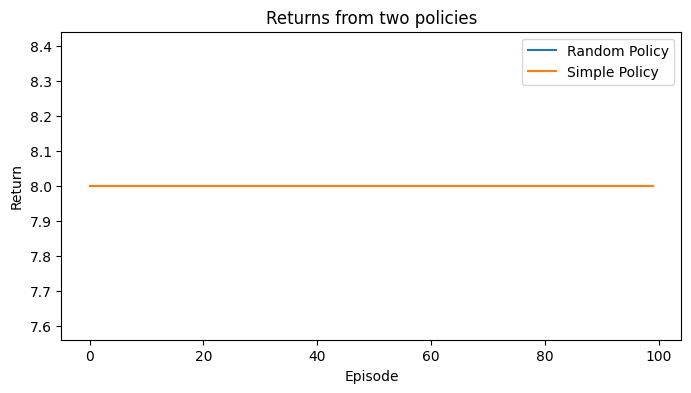

In [10]:
random_returns = collect_returns(random_policy, num_episodes = 100)
simple_returns = collect_returns(simple_policy, num_episodes = 100)

plt.figure(figsize = (8,4))
plt.plot(random_returns, label = "Random Policy")
plt.plot(simple_returns, label = "Simple Policy")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Returns from two policies")
plt.legend()
plt.show()